# OBJECTIVE

As mentioned in analysis.ipynb, we aim to create a predictive model for Airbnb pricing in Malaga. The main goal of this is to **help unexperienced hosts** set **fair prices** for their listings, based on all previous ones. 

Although I only mentioned new hosts, this *could* also be useful for **experienced ones**. For example, if a host transitions into Superhost status, should he raise his prices? And by how much? Or if an existing listing is doing poorly and has bad reviews, should he lower the price? And by how much?

In [1]:
""" IMPORTING THE CLEANED DATA """

import numpy as np
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

CLEANED_PATH = PROJECT_ROOT / "data" / "listings_cleaned.csv"

df = pd.read_csv(CLEANED_PATH)

## Feature engineering

First, we need to decide **what features to keep**, add any needed **extra features**, **modify/scale** existing numerical data if needed, and **encode** categorical variables.

- Note that all of this can be modified later on, if needed (e.g. for a certain model).

- Also note we do **not** need to worry about *missing values*, since those were already taken care of in data_cleaning.py. We have also engineered certain features already: (luxury, seasonal availability)

In [2]:
# Let's see all our features
print(df.columns)

Index(['id', 'name', 'description', 'host_id', 'neighbourhood_cleansed',
       'latitude', 'longitude', 'property_type', 'room_type', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'host_since', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_listings_count', 'host_total_listings_count',
       'host_identity_verified', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'number_of_reviews',
       'reviews_per_month', 'instant_bookable', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'estimated_occupancy_l365d', 'price',
       'minimum_nights', 'maximum_nights', 'last_scraped',
       'calendar_last_scraped', 'num_amenities', 'is_luxury',
       'spring_avail_rate', 'spring_available', 'summer_avail_r

### Single vs. Multi-hosts

Although our plot was crowded and hard to interpret, it might still be useful to note down if a host has one, or multiple listings. Let's add it:

In [3]:
df['is_multi_host'] = (df['host_listings_count'] > 1).astype(int)

It could also be useful if we **combine multiple host-related features** into one combined "engagement score", and use it as a replacement to avoid a high feature count.

In [4]:
df['host_engagement_score'] = df[
    ['host_response_rate', 'host_acceptance_rate']
].mean(axis=1)

print(df[['host_response_rate', 'host_acceptance_rate', 'host_engagement_score']].head())

   host_response_rate  host_acceptance_rate  host_engagement_score
0                 1.0                  1.00                   1.00
1                 1.0                  0.72                   0.86
2                 1.0                  1.00                   1.00
3                 1.0                  0.98                   0.99
4                 1.0                  0.78                   0.89


### Review scores

The same logic can be applied here, merging 7 features into one: 

In [5]:
review_cols = [
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value'
]

df['review_score_mean'] = df[review_cols].mean(axis=1)

print(df[review_cols + ['review_score_mean']].head())


   review_scores_rating  review_scores_accuracy  review_scores_cleanliness  \
0                  4.60                    4.71                       4.61   
1                  4.72                    4.60                       4.50   
2                  4.53                    4.63                       4.73   
3                  4.80                    4.86                       4.85   
4                  4.77                    4.85                       4.67   

   review_scores_checkin  review_scores_communication  review_scores_location  \
0                   4.88                         4.93                    4.43   
1                   4.83                         4.91                    4.80   
2                   4.66                         4.60                    4.49   
3                   4.85                         4.80                    4.72   
4                   4.94                         4.97                    4.81   

   review_scores_value  review_score_mean  


Since review counts are heavily **skewed**, the last thing we will add is their **log-transformed** count:

In [6]:
df['number_of_reviews_log'] = np.log1p(df['number_of_reviews'])

print(df[['number_of_reviews', 'number_of_reviews_log']].head())

   number_of_reviews  number_of_reviews_log
0                250               5.525453
1                101               4.624973
2                 60               4.110874
3                301               5.710427
4                388               5.963579


### Target variable (price)

Since prices are heavily **skewed** as well (seen in plots), we will **log-transform** it as well and work with it:

In [7]:
df['log_price'] = np.log1p(df['price'])

### Feature selection (column reduction)

Let's finally get rid of all columns we don't need for modeling anymore, and only keep relevant ones. Note that future predictions will have to be passed in this form as well, which means we might need some sort of *converter* before deployment (was included in app.py later on).

In [8]:
df_reduced = df.drop([
    'id', 'name', 'description', 'host_id',
    'host_response_rate', 'host_acceptance_rate', 'host_since',
    'number_of_reviews', 'review_scores_rating',
    'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value',
    'availability_30', 'availability_60',
    'availability_90', 'availability_365', # Availability is already included by season
    'last_scraped', 'calendar_last_scraped',
    'spring_available', 'summer_available', 'fall_available', 'winter_available',
    'price', 'is_luxury' # MUST DROP (price related, dependant from target)
    ], axis=1)

## Train-test split

Standard procedure to simulate unseen data, done for accurate testing to prevent overfitting.

In [9]:
from sklearn.model_selection import train_test_split

X = df_reduced.drop(columns=['log_price'])
y = df_reduced['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=25)

## Preprocessing (scaling, encoding), Pipeline

Since our data has categorical and numerical features, we need to: **scale numericals**, and **encode categoricals**. We can automate all of this into a pipeline like so:

In [10]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso

categorical_cols = ['room_type', 'property_type', 'neighbourhood_cleansed', 'host_response_time']  # OHE
binary_cols = ['instant_bookable', 'has_availability', 'host_is_superhost',
               'host_identity_verified', 'is_multi_host']  # keep as-is
numeric_cols = [c for c in X.columns 
                if c not in categorical_cols + binary_cols] # scale

preprocessor = ColumnTransformer(force_int_remainder_cols=False,
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ],
    remainder='passthrough'  # so binaries are kept as-is
)

pipe = Pipeline(steps=[('preprocessor', preprocessor), 
                       ('model', Lasso(alpha=0.01, max_iter=10000, random_state=25))])

pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['room_type', 'property_type',
                                                   'neighbourhood_cleansed',
                                                   'host_response_time']),
                                                 ('num', StandardScaler(),
                                                  ['latitude', 'longitude',
                                                   'accommodates', 'bathrooms',
                                                   'bedrooms', 'beds',
                                                   'host_listings_count',
                                                   'host_total_listings_count',
                                                   'reviews_per_month',
                                                   'estimated_occupancy_l365d',
                                                   'minimum_nights',
                                                   'maximum_nights',
                                                   'num_amenities',
                                                   'spring_avail_rate',
                                                   'summer_avail_rate',
                                                   'fall_avail_rate',
                                                   'winter_avail_rate',
                                                   'host_engagement_score',
                                                   'review_score_mean',
                                                   'number_of_reviews_log'])])),
                ('model', Lasso(alpha=0.01, max_iter=10000, random_state=25))])

In [11]:
# NOTE: Our goal is to extract feature importance

# Transform training data to see final feature matrix
X_transformed = pipe.named_steps['preprocessor'].transform(X_train)

print("Transformed shape:", X_transformed.shape)
print("Number of coefficients:", pipe.named_steps['model'].coef_.shape[0])
# These must match

# For OHE features, get names
ohe_features = pipe.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)

# For numeric features, take the number from transformed array
n_numeric = len(numeric_cols)
numeric_features = numeric_cols[:n_numeric]  # safe slice

# For binary features, leave them as they are
binary_features = binary_cols

# Combine feature names exactly in order
all_features = list(ohe_features) + numeric_features + binary_features

# Now match coefficients
coefs = pipe.named_steps['model'].coef_

feature_importance = pd.DataFrame({
    'feature': all_features,
    'coefficient': coefs,
    'abs_coefficient': np.abs(coefs)
}).sort_values(by='abs_coefficient', ascending=False)

print(feature_importance.head(24))

Transformed shape: (6928, 84)
Number of coefficients: 84
                                      feature  coefficient  abs_coefficient
0                   room_type_Entire home/apt     0.391725         0.391725
61                               accommodates     0.182746         0.182746
30  property_type_Private room in rental unit    -0.142696         0.142696
65                        host_listings_count     0.109046         0.109046
62                                  bathrooms     0.086561         0.086561
63                                   bedrooms     0.064225         0.064225
66                  host_total_listings_count     0.059918         0.059918
47              neighbourhood_cleansed_Centro     0.058843         0.058843
68                  estimated_occupancy_l365d    -0.055656         0.055656
77                          review_score_mean     0.053246         0.053246
59                                   latitude    -0.031130         0.031130
72                          spr

^^^ Note that One-Hot-Encoder has turned **categorical features into multiple columns** (binary flags), hence the weird feature names above. For example: neighbourhood_cleansed_Centro, is just a binary flag for if 'neighbourhood_cleansed' is equal to Centro.

After looking at coefficients, we see the following features are **irrelevant**: ['latitude', 'longitude', 'summer_avail_rate', 'spring_avail_rate', 'number_of_reviews_log', 'reviews_per_month', 'num_amenities', 'minimum_nights', 'maximum_nights']

We will also drop 'host_listings_count', since it is dependent on only this dataset, and 'host_total_listings_count' is much more logical.

We will still keep 'host_engagement_score' since it makes sense to include it, considering our goal (host information is needed).

In [12]:
# Getting dataframe down to final form
df_reduced = df_reduced.drop(['latitude', 'longitude', 'summer_avail_rate', 
                              'spring_avail_rate', 'number_of_reviews_log', 
                              'reviews_per_month', 'num_amenities', 'host_listings_count', 
                              'minimum_nights', 'maximum_nights'], axis=1)
print(df_reduced.columns)

Index(['neighbourhood_cleansed', 'property_type', 'room_type', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'host_response_time',
       'host_is_superhost', 'host_total_listings_count',
       'host_identity_verified', 'instant_bookable', 'has_availability',
       'estimated_occupancy_l365d', 'fall_avail_rate', 'winter_avail_rate',
       'is_multi_host', 'host_engagement_score', 'review_score_mean',
       'log_price'],
      dtype='object')


Now that we've finally reduced our features as much as possible for now, we need to redefine the X and y split.

In [13]:
X = df_reduced.drop(columns=['log_price'])
y = df_reduced['log_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=25
)

# Update preprocessing (change of numeric columns)
numeric_cols = [c for c in X.columns if c not in categorical_cols + binary_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ],
    remainder='passthrough'  # so binaries are kept as-is
)

## Training

We are ready to start training/testing different types of models. We will *stay away* from linear regression models, since we can see their performance not being the best, just based off of the Lasso score above.

Therefore, we will move to a **tree-based model**: **XGBoost** (SKLearn Random Forests won't perform better, if we optimize XGB).

In [14]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import uniform, randint

# Pipeline with preprocessor and XGB model
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        objective='reg:squarederror', 
        random_state=25,
        n_jobs=-1,
        tree_method='hist'  # faster training
    ))
])

# Hyperparameter distributions for RS
param_dist = {
    'model__n_estimators': randint(300, 700),
    'model__learning_rate': uniform(0.02, 0.1),
    'model__max_depth': randint(3, 10),
    'model__subsample': uniform(0.7, 0.3),   # [0.7, 1.0]
    'model__colsample_bytree': uniform(0.7, 0.3),  # [0.7, 1.0]
    'model__min_child_weight': randint(1, 5)
}

# RandomizedSearchCV (faster than full grid)
random_search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=50,   # number of random combos to try
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=25,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV RMSE:", -random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'model__colsample_bytree': np.float64(0.7276566725898743), 'model__learning_rate': np.float64(0.03717043794679441), 'model__max_depth': 8, 'model__min_child_weight': 2, 'model__n_estimators': 471, 'model__subsample': np.float64(0.8685736549554467)}
Best CV RMSE: 0.42728729192962234


## Testing & Interpretation

Now that our model is trained, let's test it on a set of unseen testing data from earlier, as well as analyze our model.

### Why/What to interpret?

Understanding **feature importance** on our model is *crucial*, since it provides the host with information about what factors are key to achieving higher prices, as well as knowing **which things to advertise/list first**.

In [15]:
from sklearn.metrics import root_mean_squared_error

# Best model
best_model = random_search.best_estimator_

# Predictions (in log space)
y_pred_log = best_model.predict(X_test)

# RMSE in log space
rmse_log = root_mean_squared_error(y_test, y_pred_log)

# Convert back to actual price space
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

rmse_price = root_mean_squared_error(y_true, y_pred)

mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100


print(f"Test RMSE (log-price): {rmse_log:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Test RMSE (log-price): 0.4580
Mean Absolute Percentage Error (MAPE): 30.63%


This means **on average**, our model predicts price with a **~30% error**, which is actually quite good, since:

    - AirBnb data is naturally extremely noisy
    - Lots of **unseen, but still very important factors**: photos, exact location, time-specific demand, cleaning fees, local events, even subjective value...

In [16]:
# Get feature names from preprocessor
ohe_features = best_model.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .get_feature_names_out(categorical_cols)

all_features = list(ohe_features) + numeric_cols + binary_cols

# Extract booster feature importances
xgb_model = best_model.named_steps['model']
importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({
    'feature': all_features,
    'importance': importance
}).sort_values(by='importance', ascending=False)

print(feature_importance.head(10))

                                            feature  importance
0                         room_type_Entire home/apt    0.305185
2                            room_type_Private room    0.125815
60                                        bathrooms    0.044755
30        property_type_Private room in rental unit    0.044274
63                        host_total_listings_count    0.035837
59                                     accommodates    0.025409
61                                         bedrooms    0.023687
20                       property_type_Entire villa    0.022816
70                                 has_availability    0.016964
21  property_type_Private room in bed and breakfast    0.016323


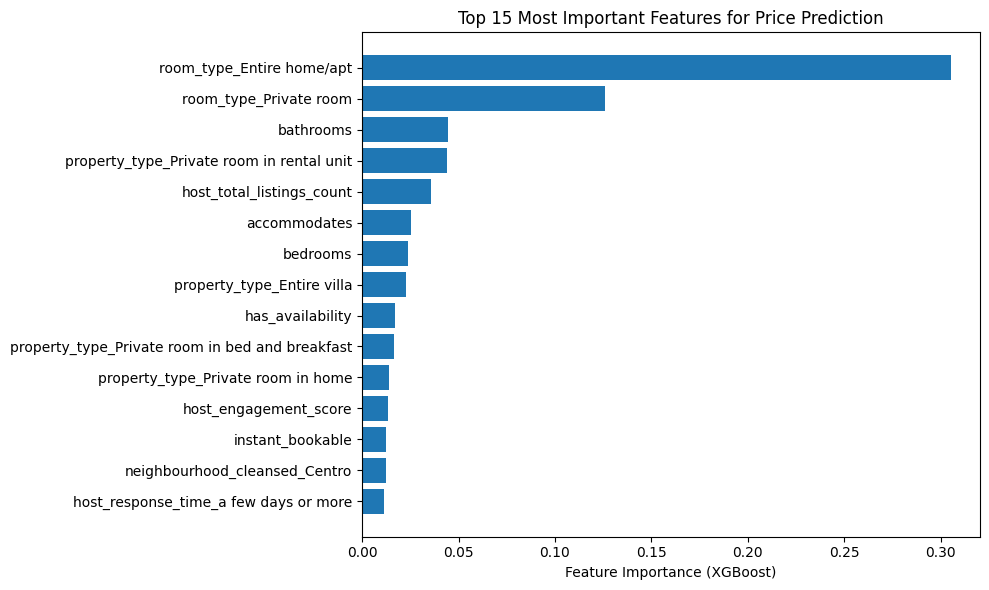

In [17]:
import matplotlib.pyplot as plt

top_features = feature_importance.sort_values(by="importance", ascending=False).head(15)

# Visualization of Top 15 Features
plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.xlabel("Feature Importance (XGBoost)")
plt.title("Top 15 Most Important Features for Price Prediction")
plt.tight_layout()
plt.show()

### Interpretation

The results suggest that **structural listing characteristics (room type, capacity, amenities)** are the strongest drivers of price,  
while **host-related attributes** and **neighborhoods** provide secondary but still meaningful contributions.

## Exporting model + pipeline

Now that our model is trained/tested, we need to make it **accessible/usable for casual users** (in our case, hosts).

Our goal is to create a **simple tool** that allows for entering a data sample with only the required features, processes it automatically and outputs a price prediction.

In [34]:
import joblib

best_model = random_search.best_estimator_ # the pipelime with the optimized model

# Save the full pipeline
joblib.dump(best_model, "airbnb_price_model.pkl")

['airbnb_price_model.pkl']

## Deployment

We will deploy our model for **easy access** (for casual users) using **Streamlit**.

For **instructions on how to use**, check README.txt.